<a href="https://colab.research.google.com/github/prasadw350-lang/Assignments/blob/main/Assignment22(Optional).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

import joblib

In [7]:
filepath = "/content/drive/MyDrive/diabetes_prediction_dataset.csv"
df = pd.read_csv(filepath)

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [40]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000,96146.000000
mean,41.794326,0.077601,0.040803,27.321461,5.532609,138.218231,0.088220
std,22.462948,0.267544,0.197833,6.767716,1.073232,40.909771,0.283616
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.400000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,59.000000,0.000000,0.000000,29.860000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [25]:

df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


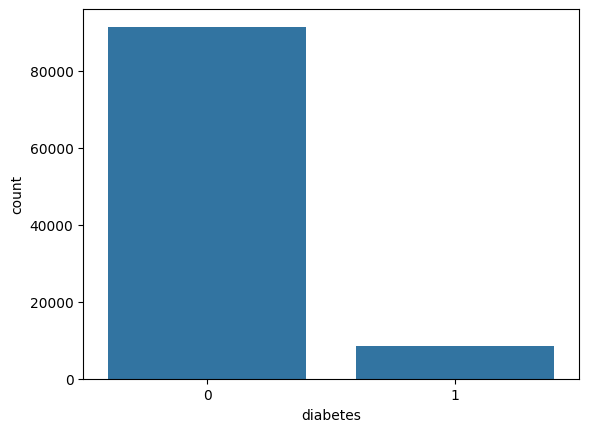

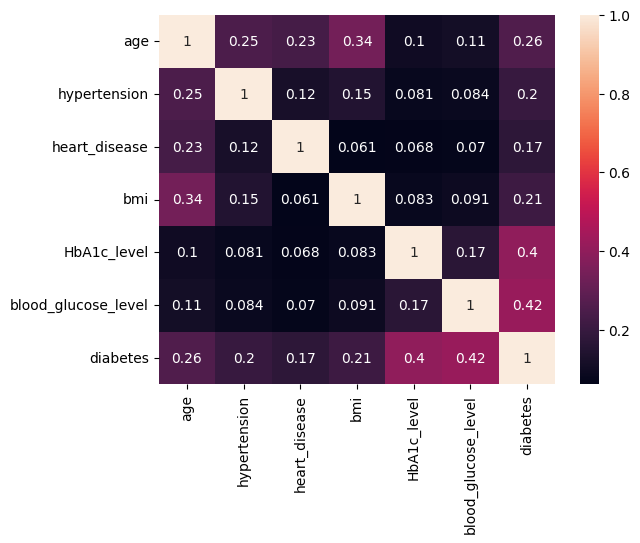

In [17]:
sns.countplot(x="diabetes", data=df)
plt.show()

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [29]:
df.duplicated().sum()

np.int64(0)

In [30]:
df.drop_duplicates(inplace=True)

df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [33]:
X = df.drop("diabetes", axis=1)

y = df["diabetes"]
X = pd.get_dummies(X)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.20,
    random_state=42

)

In [37]:
scaler = StandardScaler()

X_train = pd.DataFrame(

    scaler.fit_transform(X_train),
    columns=X_train.columns

)

X_test = pd.DataFrame(

    scaler.transform(X_test),
    columns=X_test.columns

)

In [38]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [39]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[0 0 1 0 0 0 0 0 0 0]


In [41]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print("TN =", TN)
print("FP =", FP)
print("FN =", FN)
print("TP =", TP)

[[17325   184]
 [  641  1080]]
TN = 17325
FP = 184
FN = 641
TP = 1080


In [42]:
print("Accuracy :", accuracy_score(y_test,y_pred))

print("Precision :", precision_score(y_test,y_pred))

print("Recall :", recall_score(y_test,y_pred))

print("F1 Score :", f1_score(y_test,y_pred))

print(classification_report(y_test,y_pred))

Accuracy : 0.9570982839313572
Precision : 0.8544303797468354
Recall : 0.6275421266705404
F1 Score : 0.7236180904522613
              precision    recall  f1-score   support

           0       0.96      0.99      0.98     17509
           1       0.85      0.63      0.72      1721

    accuracy                           0.96     19230
   macro avg       0.91      0.81      0.85     19230
weighted avg       0.95      0.96      0.95     19230



In [44]:
joblib.dump(model,"diabetes_model.pkl")

joblib.dump(scaler,"scaler.pkl")

joblib.dump(X.columns.tolist(),"columns.pkl")
print("Saved Successfully!")

Saved Successfully!


In [45]:
model = joblib.load("diabetes_model.pkl")

scaler = joblib.load("scaler.pkl")

columns = joblib.load("columns.pkl")

sample = pd.DataFrame({

    "gender":["Male"],
    "age":[55],
    "hypertension":[1],
    "heart_disease":[0],
    "smoking_history":["former"],
    "bmi":[32.5],
    "HbA1c_level":[7.2],
    "blood_glucose_level":[220]

})

sample = pd.get_dummies(sample)

sample = sample.reindex(columns=columns,fill_value=0)

sample = pd.DataFrame(

    scaler.transform(sample),

    columns=columns

)

prediction = model.predict(sample)

if prediction[0]==1:

    print("Diabetes : YES")

else:

    print("Diabetes : NO")

Diabetes : YES
